In [1]:
parquet_path = "../../../../results/evaluation/results_EN_NPO_e20-ue3-subset.parquet"
subset_csv_path = "../../../results/evaluation/results_NL_NPO_e20-ue31.csv"

In [2]:
from psalm.evaluators.analyzer import UnlearningAnalyzer

analyzer = UnlearningAnalyzer(parquet_path)

Dataset loaded:
  Forget samples: 20
  Retain samples: 20
  Total metrics: 13



STARTING COMPREHENSIVE UNLEARNING ANALYSIS

1. Calculating statistics...
   ✓ Statistics calculated for 13 metrics

2. Detecting outliers...
   ✓ Found 6 outliers

3. Generating visualizations...
✓ Saved comparison_boxplots.png
✓ Saved metric_heatmap.png
✓ Saved category_comparison.png
✓ Saved violin_distributions.png
✓ Saved correlation_matrix.png
✓ Saved outlier_analysis.png
✓ Saved author_comparison.png

4. Generating summary report...
UNLEARNING ANALYSIS SUMMARY REPORT

DATASET OVERVIEW:
  Total samples: 40
  Forget samples: 20
  Retain samples: 20
  Unique authors: 9

MEMORIZATION REMOVAL (Lower is better for Forget):
--------------------------------------------------------------------------------
  Exact Match:
    Forget: 0.0000 | Retain: 0.5500 | Δ: -0.5500
    p-value: 0.000129 (***) | Cohen's d: -1.524
    Effect size: large

  BLEU:
    Forget: 0.1983 | Retain: 0.7670 | Δ: -0.5687
    p-value: 0.000001 (***) | Cohen's d: -2.516
    Effect size: large

  ROUGE:
    Forget: 0

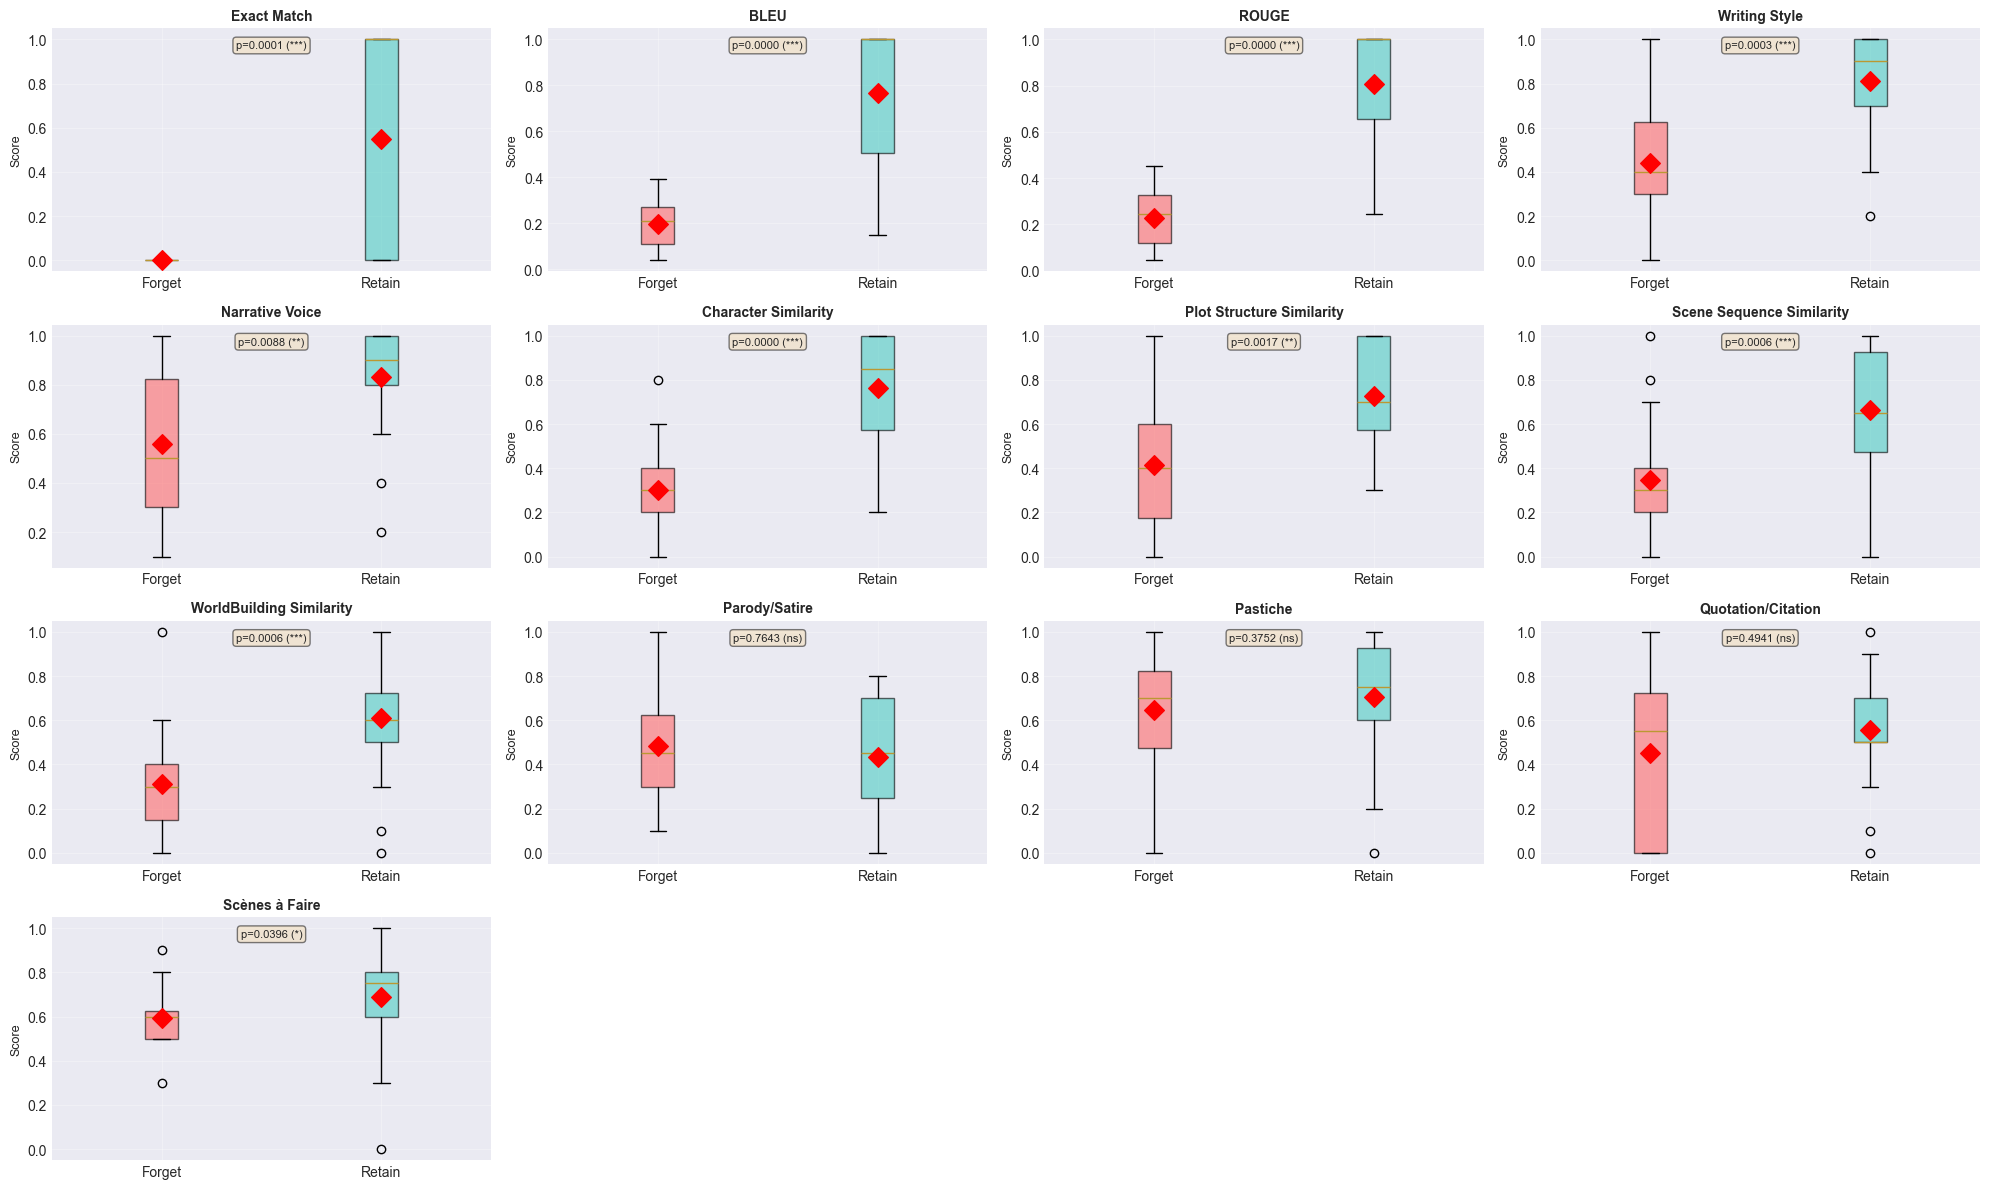

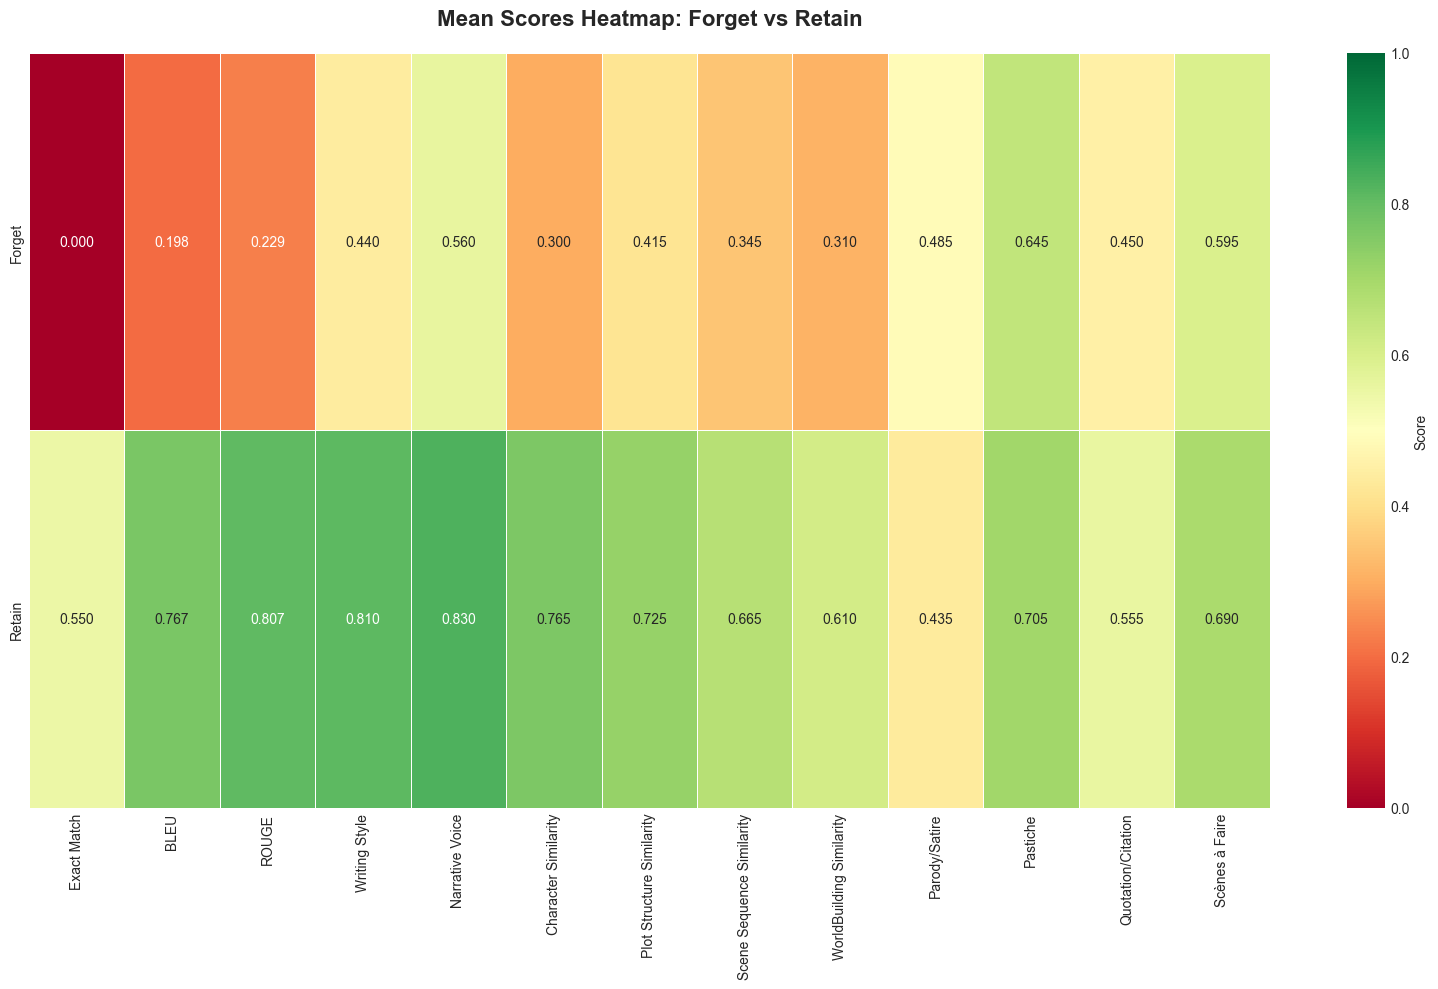

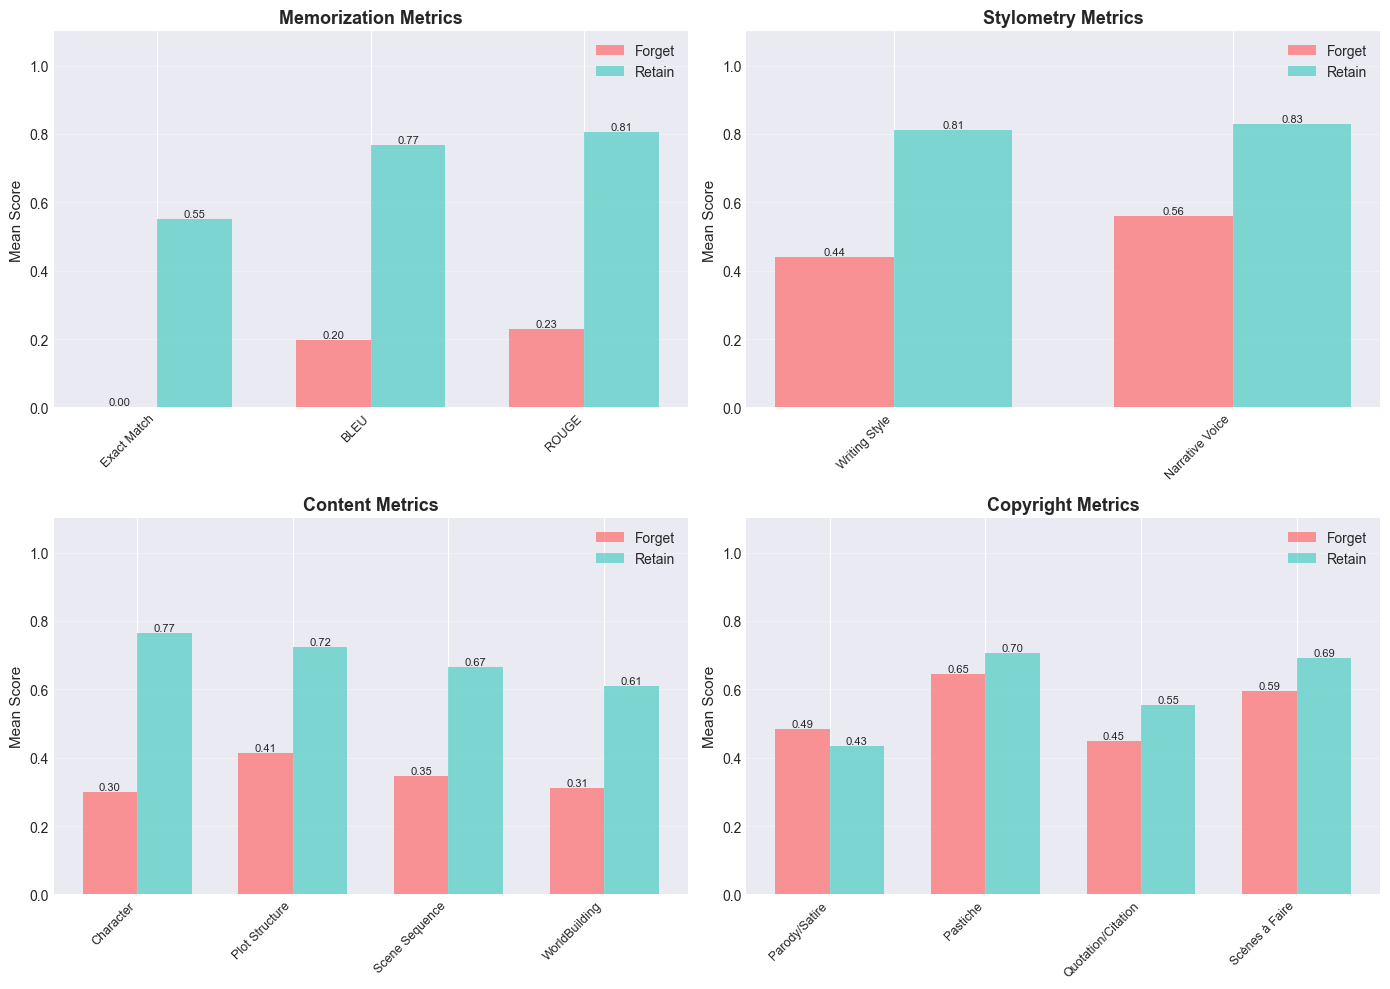

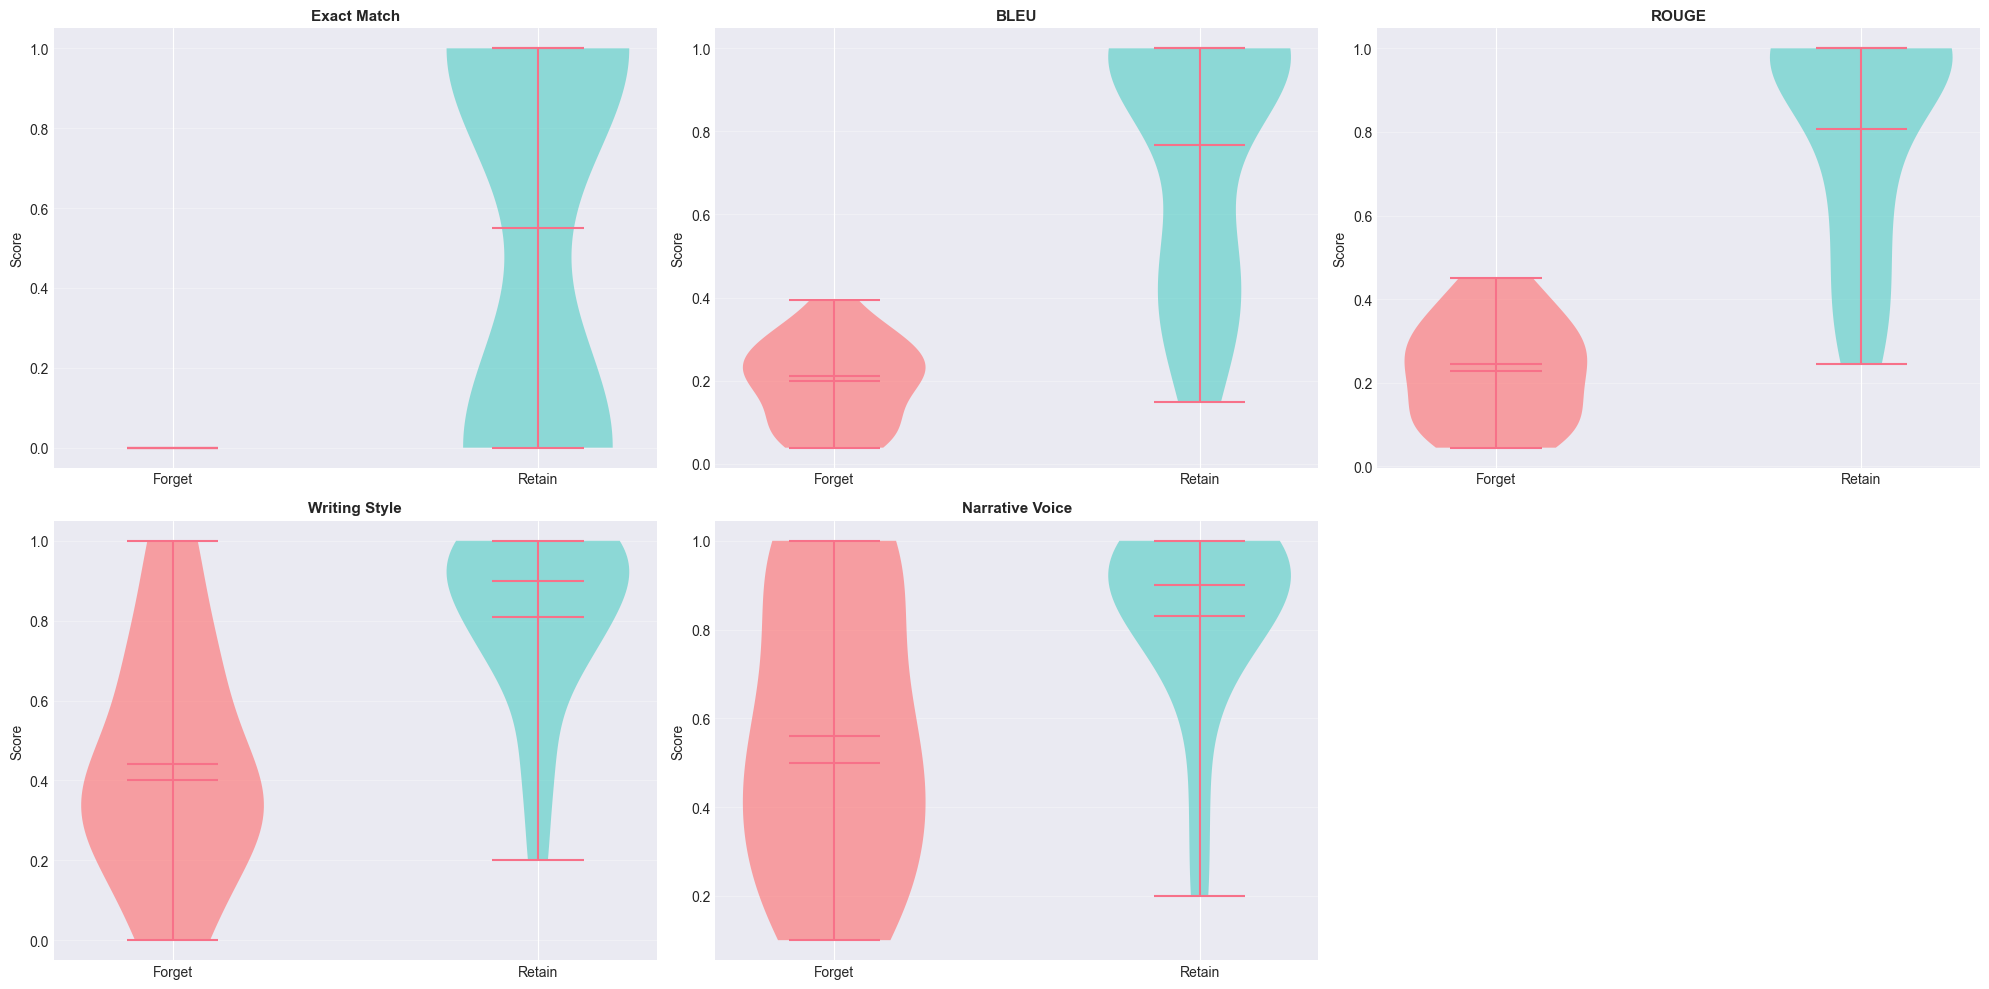

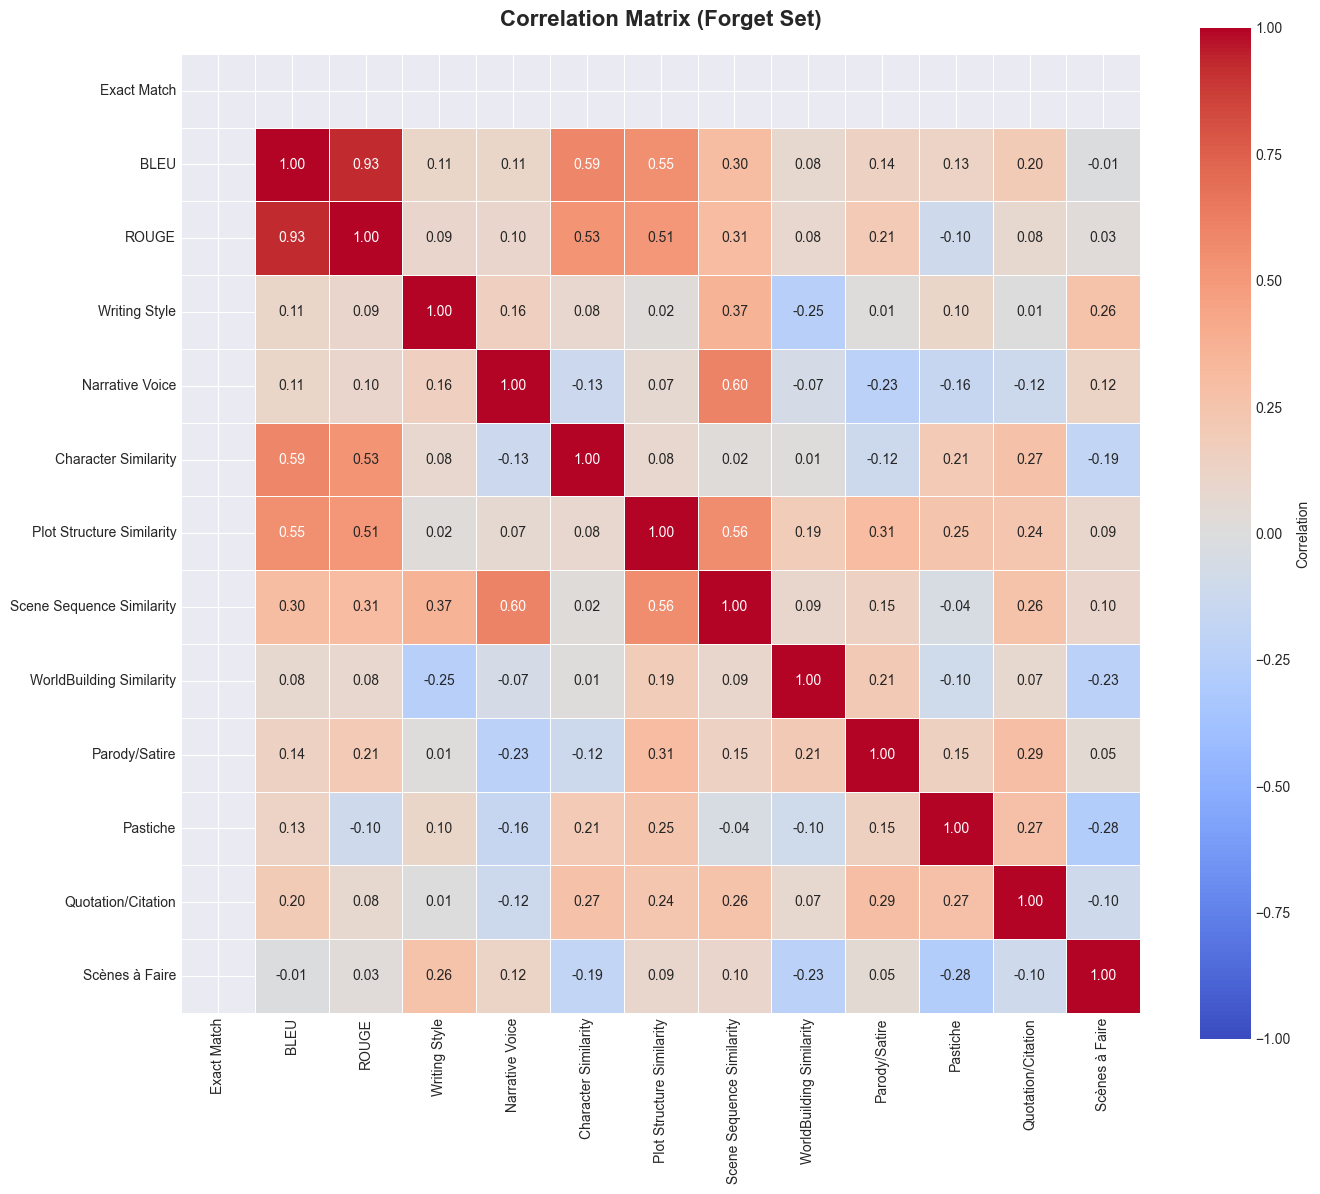

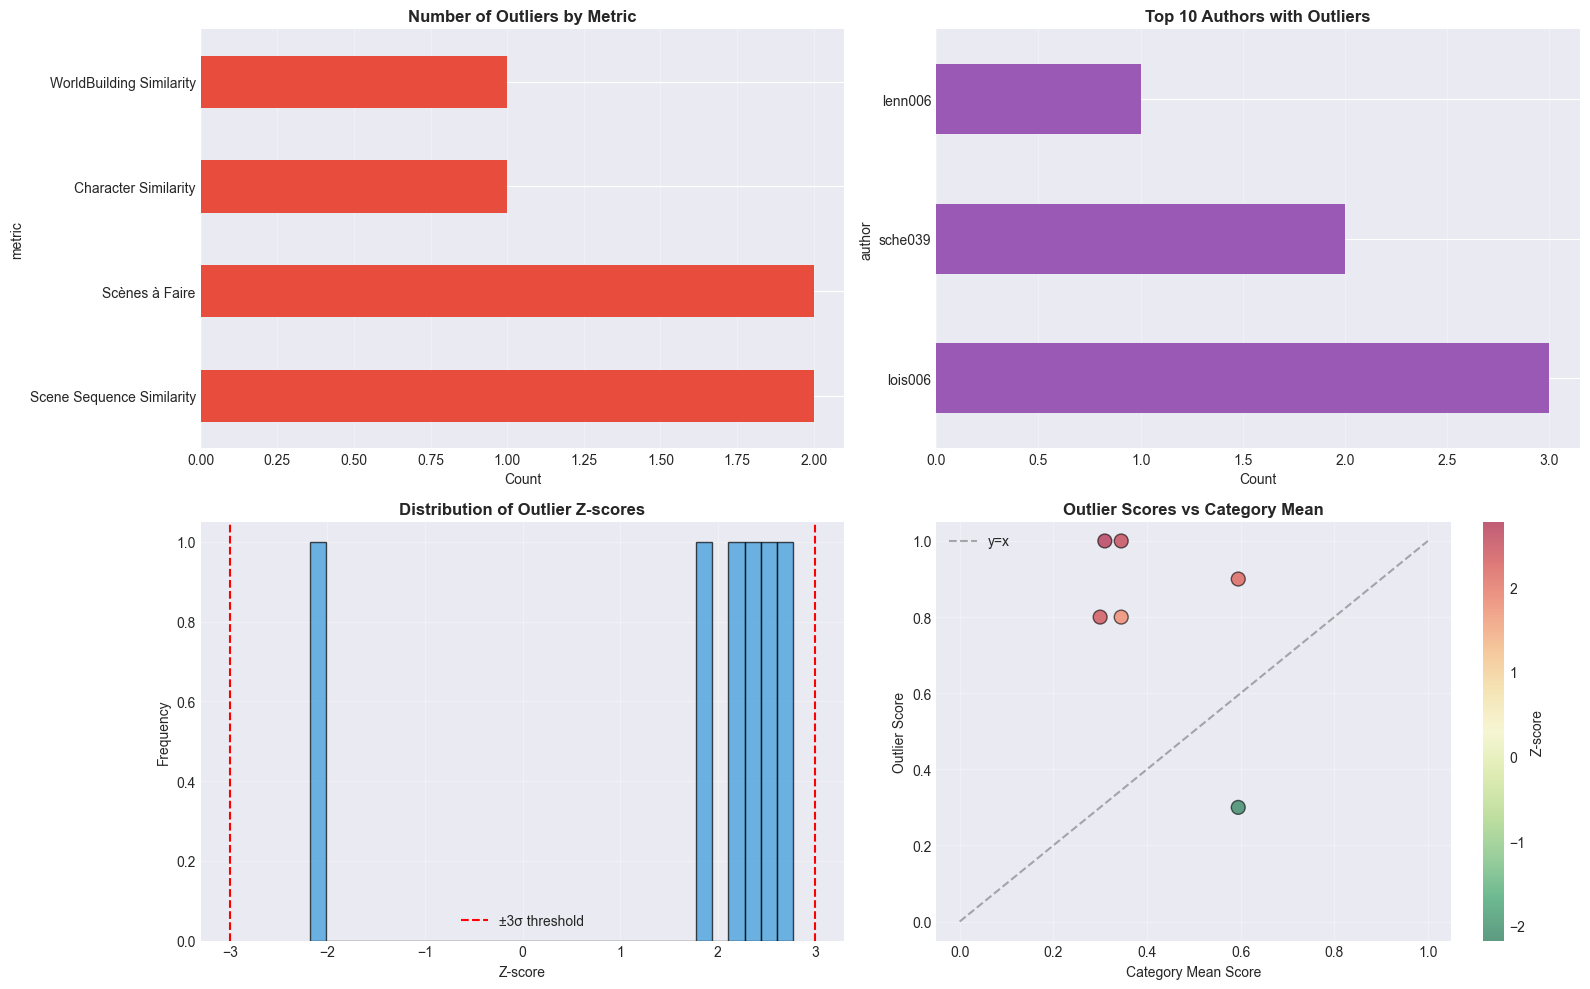

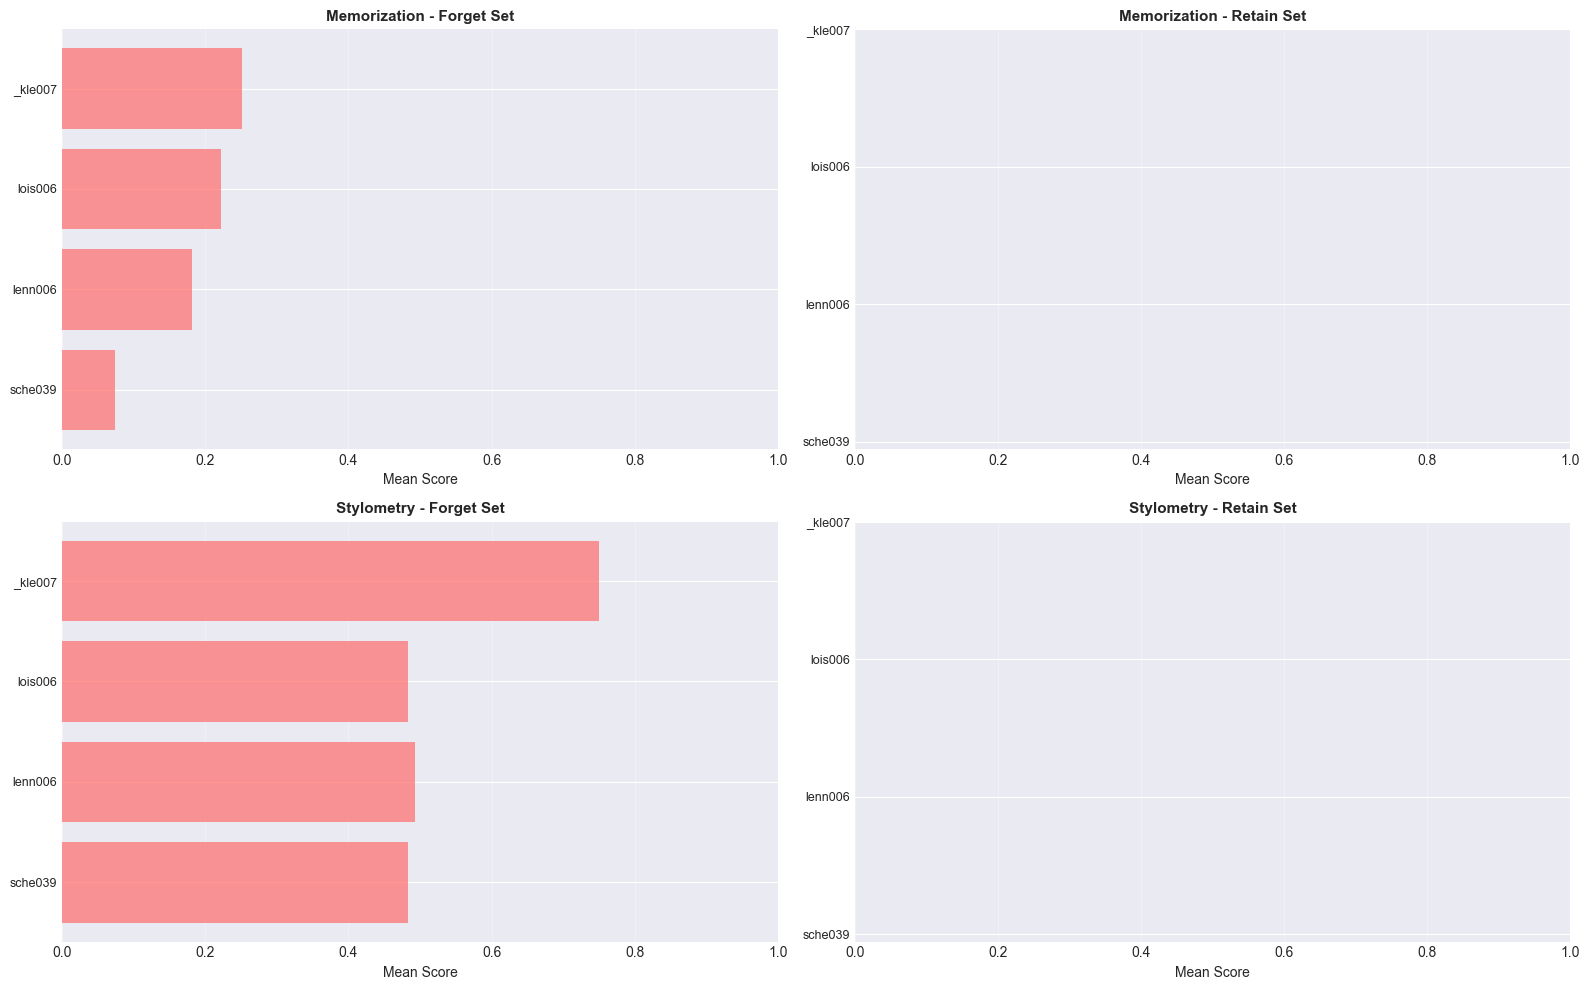

In [3]:
analyzer.run_full_analysis()

In [5]:
print("\n" + "="*80)
print("TOP 10 MOST EXTREME OUTLIERS:")
print("="*80)
if len(analyzer.outliers_df) > 0:
    top_outliers = analyzer.outliers_df.nlargest(10, 'z_score')
    for idx, row in top_outliers.iterrows():
        print(f"\n{row['test_id']} - {row['author']}")
        print(f"  Metric: {row['metric']}")
        print(f"  Score: {row['score']:.4f} (Mean: {row['mean']:.4f}, Std: {row['std']:.4f})")
        print(f"  Z-score: {row['z_score']:.2f}")
        print(f"  Reason: {row['reason'] if row['reason'] is not None else ''}...")
        print(f"  Is Forget: {row['is_forget']}")
        print(f"  Question: {row['question']}")
        print(f"  Expected Answer: {row['expected_answer'][:200]}...")
        print(f"  Actual Answer: {row['actual_answer'][:200]}...")


TOP 10 MOST EXTREME OUTLIERS:

sche039tore01 - sche039
  Metric: WorldBuilding Similarity
  Score: 1.0000 (Mean: 0.3100, Std: 0.2490)
  Z-score: 2.77
  Reason: The DAG path for WorldBuilding Similarity [DAG] begins at TaskNode Level 0 and proceeds through Level 1 verdicts and multiple Level 2 verdicts, culminating in Level 3 verdicts that assign very low scores on most dimensions (e.g., Geographic/Spatial Design 0/10, Historical/Temporal 0/10, World Rules/Systems 2-3/10, Cultural/Social 3/10, World Function/Logic 2-3/10) with only Material & Sensory Detail reaching 10/10. With the EU weighting (Geographic 0.25, World Rules 0.25, Cultural 0.20, Historical 0.15, Material 0.10, Function 0.05) and rounding to the nearest integer, these predominantly low values lead to a final aggregated score of 1/10. The path explicitly shows the low-scoring branches driving the result....
  Is Forget: True
  Question: Create a descriptive passage, in the style of 'Torentje torentje bossekruid, of het ee